## 1.Data Preparation

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/Users/mac/ML-spotify-features/Spotify_weeklytop200_cleaned.csv')

In [3]:
FEATURES = ['Danceability', 'Energy', 'Loudness', 'Speechiness', 
            'Acousticness', 'Instrumentalness', 'Valence']

In [7]:
df.describe()

,Weekly_Rank,Weekly_Points,Streams,Days_Charted,Peak_Rank,Year,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence
count,91709.000000,91709.000000,2.486600e+04,66843.000000,91709.000000,91709.000000,91709.000000,91709.000000,91709.000000,91709.000000,91709.000000,91709.000000,91709.000000
mean,100.855270,691.730266,1.325498e+07,6.409901,71.465821,2020.924206,0.674019,0.637001,-6.294381,0.098936,0.243802,0.012952,0.505258
std,57.647573,395.372334,7.447328e+06,1.514154,51.820375,2.558510,0.144158,0.163989,2.843034,0.093486,0.249222,0.077754,0.229334
min,1.000000,7.000000,7.459466e+06,1.000000,1.000000,2017.000000,0.093900,0.001700,-54.341000,0.023000,0.000000,0.000000,0.000000
25%,51.000000,336.000000,9.273884e+06,7.000000,24.000000,2019.000000,0.583000,0.532000,-7.395000,0.040000,0.046000,0.000000,0.333000
50%,101.000000,678.000000,1.075642e+07,7.000000,66.000000,2021.000000,0.693000,0.653000,-5.795000,0.059000,0.152000,0.000000,0.497000
75%,151.000000,1034.000000,1.427497e+07,7.000000,113.000000,2023.000000,0.780000,0.760000,-4.554000,0.115000,0.374000,0.000000,0.680000
max,200.000000,1400.000000,1.288961e+08,7.000000,200.000000,2025.000000,0.985000,0.990000,-0.484000,0.966000,0.996000,0.995000,0.982000


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURES])
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)

In [6]:
print(X_scaled_df.mean().round(4))
print(X_scaled_df.std().round(4))

Danceability       -0.0
Energy             -0.0
Loudness            0.0
Speechiness        -0.0
Acousticness        0.0
Instrumentalness    0.0
Valence             0.0
dtype: float64
Danceability        1.0
Energy              1.0
Loudness            1.0
Speechiness         1.0
Acousticness        1.0
Instrumentalness    1.0
Valence             1.0
dtype: float64


In [9]:
df[FEATURES].corr().round(2)

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence
Danceability,1.00,0.17,0.27,0.22,-0.25,-0.14,0.42
Energy,0.17,1.00,0.68,-0.00,-0.55,-0.15,0.40
Loudness,0.27,0.68,1.00,-0.03,-0.38,-0.36,0.33
Speechiness,0.22,-0.00,-0.03,1.00,-0.07,-0.04,0.02
Acousticness,-0.25,-0.55,-0.38,-0.07,1.00,0.06,-0.13
Instrumentalness,-0.14,-0.15,-0.36,-0.04,0.06,1.00,-0.14
Valence,0.42,0.40,0.33,0.02,-0.13,-0.14,1.00


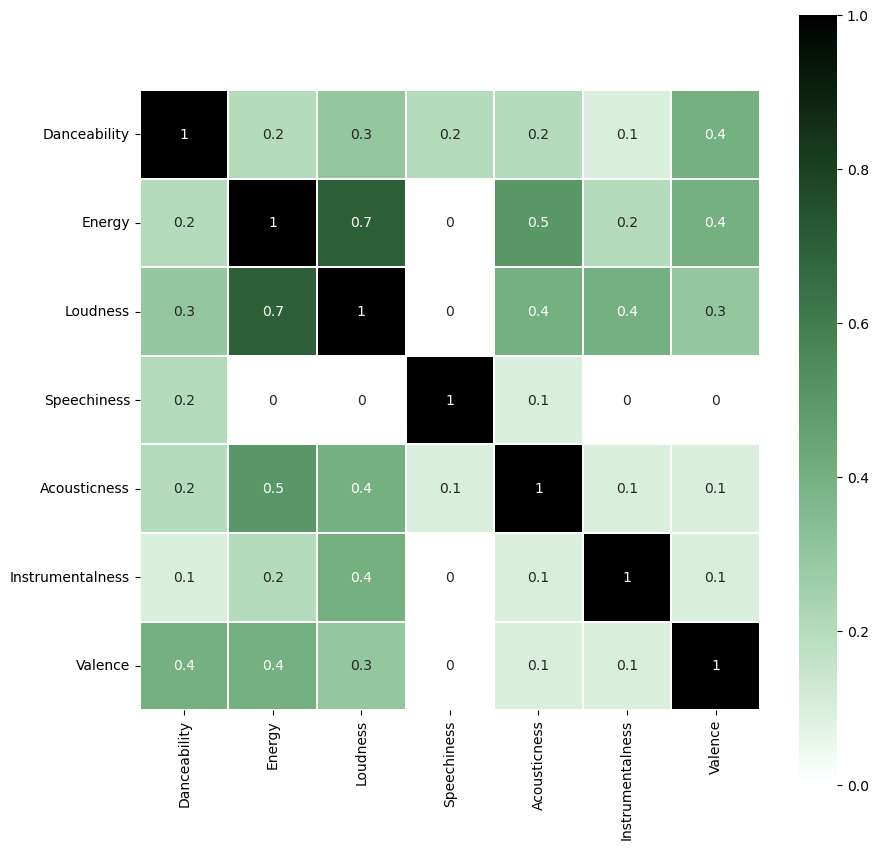

In [10]:
plt.figure(figsize=(10,10))
pal = sns.cubehelix_palette(start=2, rot=0, dark=1, light=0, reverse=True, as_cmap=True)
sns.heatmap(round(df[FEATURES].corr().abs(),1), annot=True, cmap=pal, 
            linewidths=0.2, square=True);

## 2. Number of Components

In [12]:
pca = PCA(n_components=7)
pca.fit(X_scaled)

PCA(n_components=7)

In [14]:
eigen_table = pd.DataFrame({
    'num_components': range(1, 8),
    'individual_variance': pca.explained_variance_ratio_ * 100,
    'cumulative_variance_explained': np.cumsum(pca.explained_variance_ratio_) * 100
})

print(eigen_table.round(2))

   num_components  individual_variance  cumulative_variance_explained
0               1                36.79                          36.79
1               2                16.88                          53.67
2               3                14.37                          68.04
3               4                13.19                          81.23
4               5                 9.02                          90.25
5               6                 6.48                          96.73
6               7                 3.27                         100.00


In [15]:
# Find threshold at 80%
threshold = 80
threshold_idx = (eigen_table['cumulative_variance_explained'] >= threshold).idxmax()

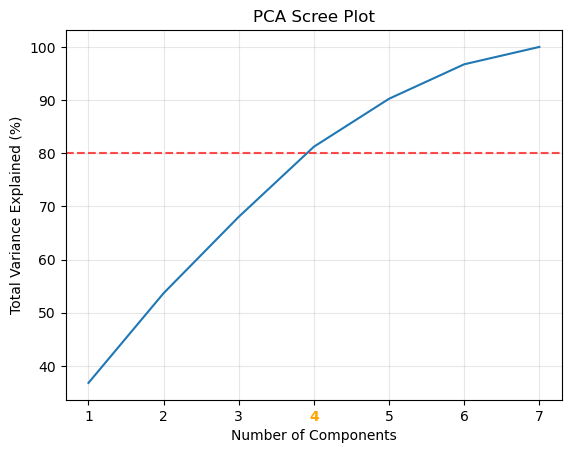

In [16]:
# Plot
plt.plot(
    eigen_table['num_components'],
    eigen_table['cumulative_variance_explained']
)
plt.axhline(y=threshold, color='red', linestyle='--', alpha=0.7)
plt.xticks(eigen_table['num_components'])
ax = plt.gca()
for label in ax.get_xticklabels():
    if int(label.get_text()) == (threshold_idx + 1):
        label.set_color('orange')
        label.set_fontweight('bold')
plt.grid(alpha=0.3)
plt.ylabel('Total Variance Explained (%)')
plt.xlabel('Number of Components')
plt.title('PCA Scree Plot')
plt.show()

## 3. Final PCA & PCA Loadings

In [17]:
N_COMPONENTS = 4

pca = PCA(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(X_scaled)

for i in range(N_COMPONENTS):
    df[f'PC{i+1}'] = X_pca[:, i]

print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")
print(f"Per PC: {[round(x, 3) for x in pca.explained_variance_ratio_]}")

Total variance explained: 0.812
Per PC: [np.float64(0.368), np.float64(0.169), np.float64(0.144), np.float64(0.132)]


In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)
print(loadings.round(3))

                    PC1    PC2    PC3    PC4
Danceability      0.338  0.560 -0.036  0.255
Energy            0.511 -0.283  0.216 -0.019
Loudness          0.508 -0.232 -0.132 -0.119
Speechiness       0.065  0.686  0.249 -0.524
Acousticness     -0.398  0.153 -0.525  0.228
Instrumentalness -0.243  0.010  0.748  0.488
Valence           0.381  0.241 -0.196  0.597


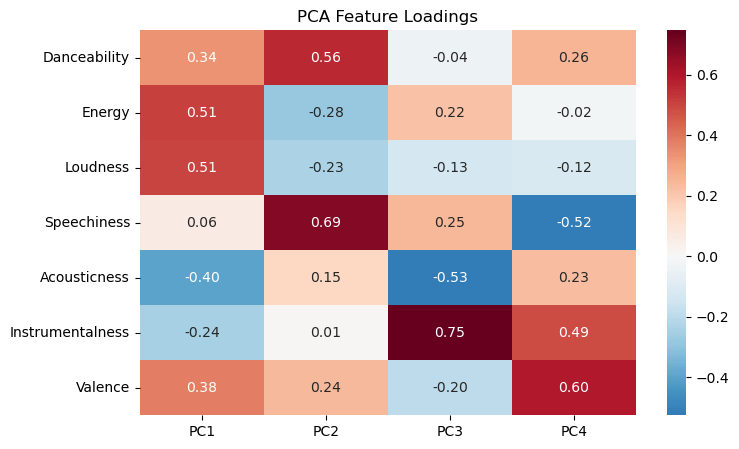

In [19]:
plt.figure(figsize=(8, 5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('PCA Feature Loadings')
plt.show()

In [20]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (91709, 25)
Columns: ['Week_End', 'Week_Start_Fri', 'Week_Label', 'Weekly_Rank', 'id', 'Title', 'Artists_All', 'Weekly_Points', 'Streams', 'Days_Charted', 'Peak_Rank', 'Stage', 'Year', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', 'Song_URL', 'PC1', 'PC2', 'PC3', 'PC4']


In [21]:
df.to_csv('/Users/mac/ML-spotify-features/df_pca.csv', index=False)